# Tesla Stock Price Prediction using RNN and LSTM

## Project Objective

The objective of this project is to forecast Tesla stock closing prices using Deep Learning techniques. Both SimpleRNN and LSTM architectures are implemented and compared to determine which model better captures stock price trends. The final solution is deployed through a Streamlit web application.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [2]:
import os
print(os.getcwd())

/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/notebook


In [3]:
df = pd.read_csv("../TSLA.csv")

## Exploratory Data Analysis

Before training the models, the dataset is examined to understand its structure, identify missing values, and observe historical trends in Tesla stock prices.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.2+ KB


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [6]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2416 non-null   datetime64[ns]
 1   Open       2416 non-null   float64       
 2   High       2416 non-null   float64       
 3   Low        2416 non-null   float64       
 4   Close      2416 non-null   float64       
 5   Adj Close  2416 non-null   float64       
 6   Volume     2416 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 132.2 KB


In [11]:
df.set_index('Date', inplace=True)

In [12]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [13]:
target = df['Close']

In [14]:
df[['Close', 'Adj Close']].head()

,Close,Adj Close
Date,,
2010-06-29,23.889999,23.889999
2010-06-30,23.830000,23.830000
2010-07-01,21.959999,21.959999
2010-07-02,19.200001,19.200001
2010-07-06,16.110001,16.110001


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2416 entries, 2010-06-29 to 2020-02-03
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2416 non-null   float64
 1   High       2416 non-null   float64
 2   Low        2416 non-null   float64
 3   Close      2416 non-null   float64
 4   Adj Close  2416 non-null   float64
 5   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 132.1 KB


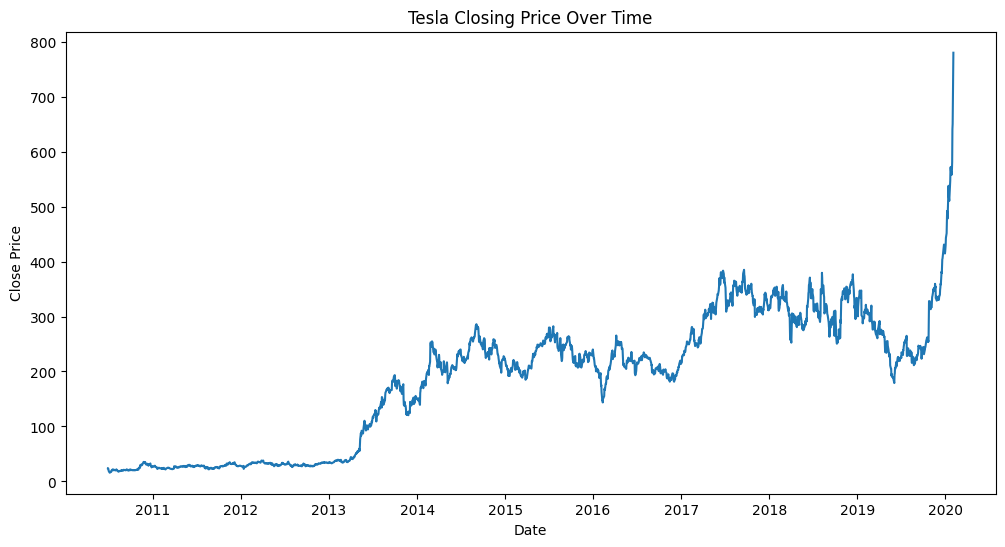

In [16]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'])

plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

### Observation

The historical closing price shows significant growth over time along with periods of volatility. This confirms that Tesla stock prices exhibit strong temporal dependencies, making them suitable for time-series forecasting models such as RNNs and LSTMs.

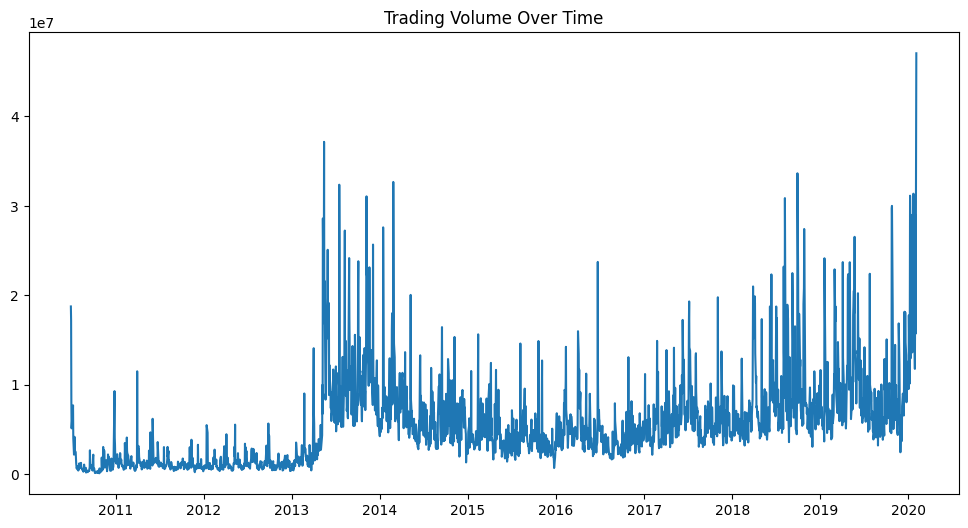

In [17]:
plt.figure(figsize=(12,6))

plt.plot(df['Volume'])

plt.title("Trading Volume Over Time")

plt.show()

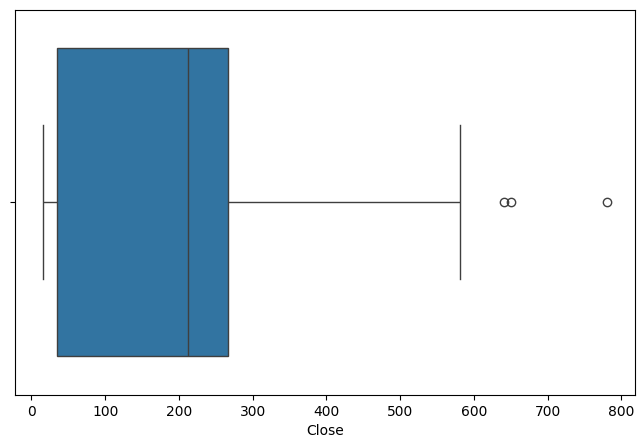

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Close'])

plt.show()

In [19]:
df['MA20'] = df['Close'].rolling(window=20).mean()

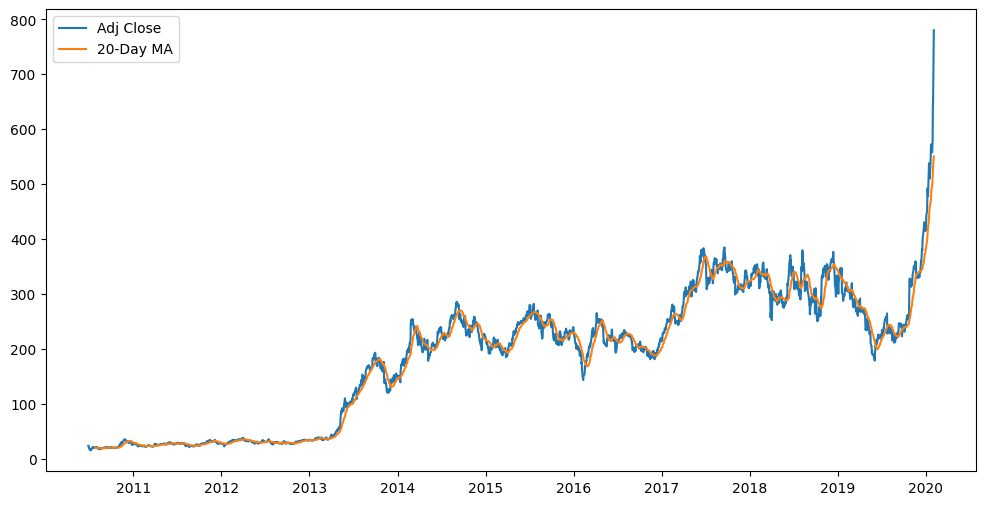

In [20]:
plt.figure(figsize=(12,6))

plt.plot(df['Adj Close'], label='Adj Close')
plt.plot(df['MA20'], label='20-Day MA')

plt.legend()
plt.show()

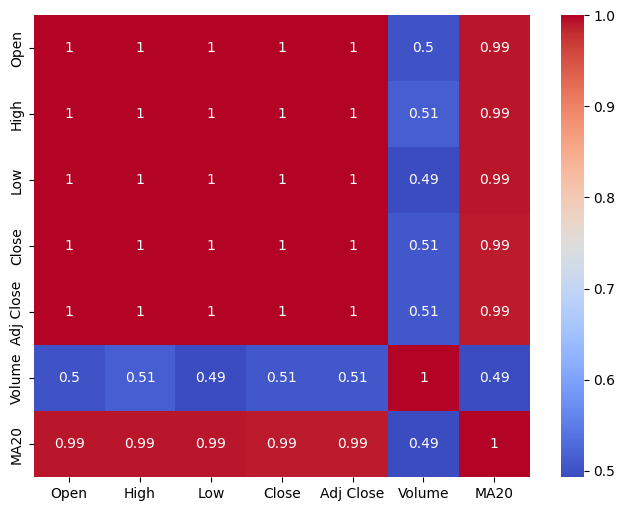

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [22]:
data = df[['Close']]

In [23]:
data.head(10)

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001
2010-07-07,15.800000
2010-07-08,17.459999
2010-07-09,17.400000
2010-07-12,17.049999


## Data Preprocessing

Neural networks perform better when input features are normalized. Therefore, MinMax Scaling is applied to transform closing prices into the range [0,1].

In [24]:


scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [25]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA20
Date,,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300,NaN
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100,NaN
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800,NaN
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800,NaN
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900,NaN


In [26]:
scaled_data[:5]

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       [0.0044491 ],
       [0.00040565]])

In [27]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA20
Date,,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300,NaN
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100,NaN
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800,NaN
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800,NaN
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900,NaN


## Time Series Window Creation

A lookback window of 60 trading days is used. The model receives the previous 60 days of stock prices as input and learns to predict future stock prices.

In [28]:
lookback = 60

In [29]:
def create_sequences(data, lookback):

    X = []
    y = []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [30]:
X, y = create_sequences(scaled_data, lookback)

In [31]:
print(X.shape)
print(y.shape)

(2356, 60, 1)
(2356, 1)


In [32]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [33]:
print(X_train.shape)
print(X_test.shape)

(1884, 60, 1)
(472, 60, 1)


In [34]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1884, 60, 1)
y_train: (1884, 1)
X_test: (472, 60, 1)
y_test: (472, 1)


In [35]:
train_data = data[:train_size]
test_data = data[train_size-lookback:]

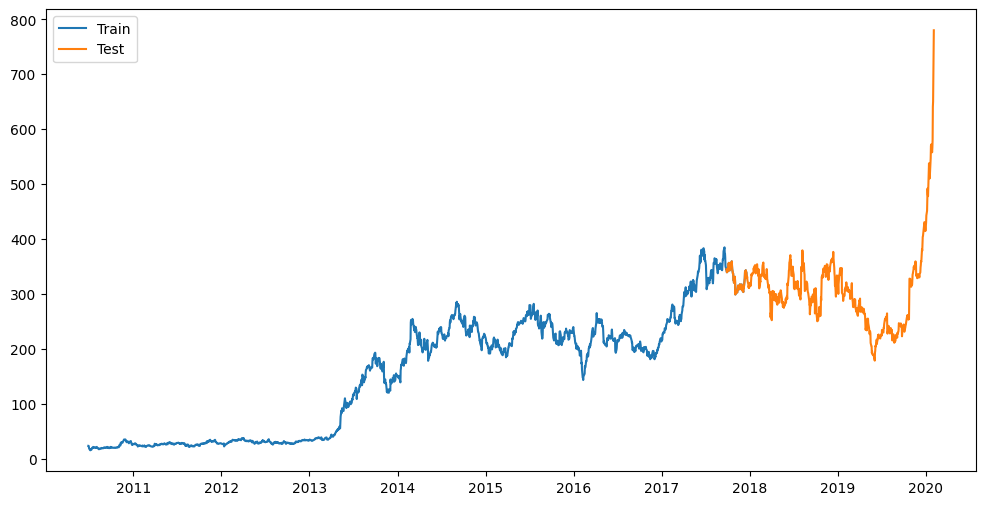

In [36]:
plt.figure(figsize=(12,6))

plt.plot(train_data.index, train_data, label='Train')
plt.plot(test_data.index, test_data, label='Test')

plt.legend()
plt.show()

In [37]:
def create_sequences(data, lookback, horizon):

    X = []
    y = []

    for i in range(lookback, len(data)-horizon+1):

        X.append(data[i-lookback:i])

        y.append(data[i+horizon-1])

    return np.array(X), np.array(y)

In [38]:
X1, y1 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=1
)

In [39]:
X5, y5 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=5
)

In [40]:
X10, y10 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=10
)

## SimpleRNN Model

A Simple Recurrent Neural Network is implemented as the baseline model. RNNs can capture sequential dependencies but may struggle with long-term memory due to the vanishing gradient problem.

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [42]:
rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(
    SimpleRNN(
        units=50
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [45]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [46]:
checkpoint = ModelCheckpoint(
    '../models/best_rnn_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [47]:
import tensorflow as tf
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [48]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices())

2.16.1
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [49]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
print(X_train.shape)
print(y_train.shape)

(1884, 60, 1)
(1884, 1)


In [51]:
print(X_train.dtype)
print(y_train.dtype)

float64
float64


In [52]:
import tensorflow as tf
print(tf.__version__)

2.16.1


In [53]:
import tensorflow as tf

print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [54]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0348 - val_loss: 0.0012
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0071 - val_loss: 8.7432e-04
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0046 - val_loss: 4.3911e-04
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032 - val_loss: 5.2315e-04
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - val_loss: 7.4280e-04
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 - val_loss: 8.0840e-04
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 - val_loss: 8.2287e-04
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0019 - val_loss: 3.7008e-04
Epoch 9/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016 - val_loss: 2.4191e-04
Epoch 10/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - val_loss: 3.0171e-04
Epoch 11/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012 - val_loss: 3.0520e-04
Epoch 12/30
53/53 ━━━━━━━━━━━━━━━━

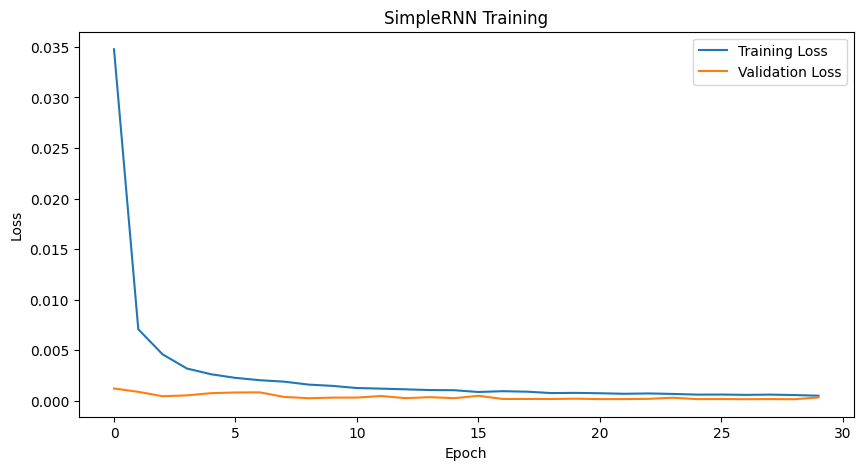

In [55]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("SimpleRNN Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

### RNN Training Analysis

The training and validation loss curves indicate how effectively the model learns patterns from the data. Stable convergence suggests successful learning, while divergence would indicate overfitting.

In [56]:
rnn_predictions = rnn_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [57]:
rnn_predictions = scaler.inverse_transform(rnn_predictions)

actual_prices = scaler.inverse_transform(y_test)

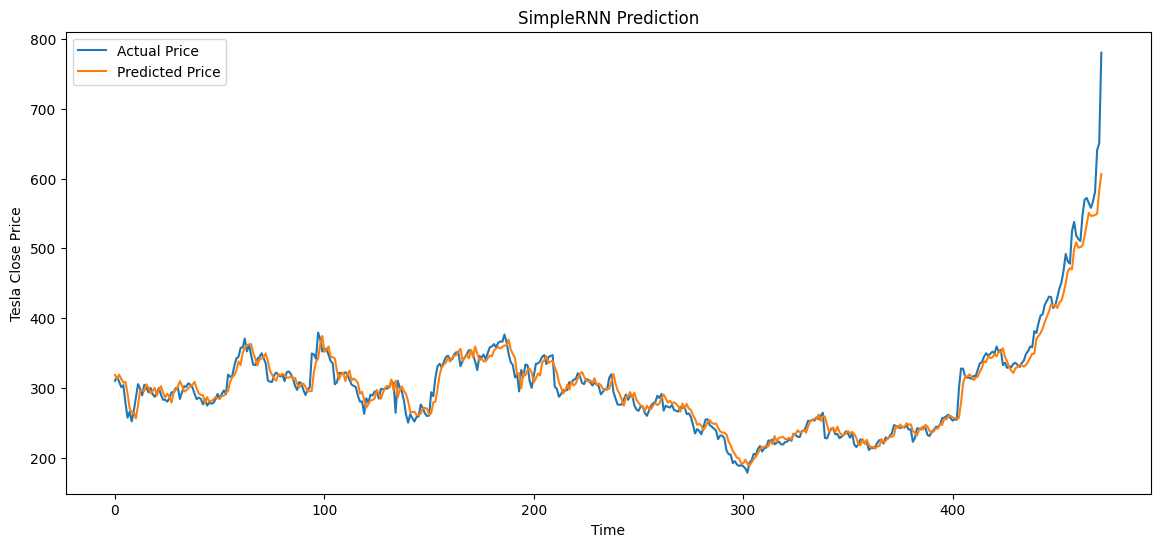

In [58]:
plt.figure(figsize=(14,6))

plt.plot(
    actual_prices,
    label='Actual Price'
)

plt.plot(
    rnn_predictions,
    label='Predicted Price'
)

plt.title("SimpleRNN Prediction")
plt.xlabel("Time")
plt.ylabel("Tesla Close Price")

plt.legend()

plt.show()

In [59]:
test_dates = data.index[-len(actual_prices):]

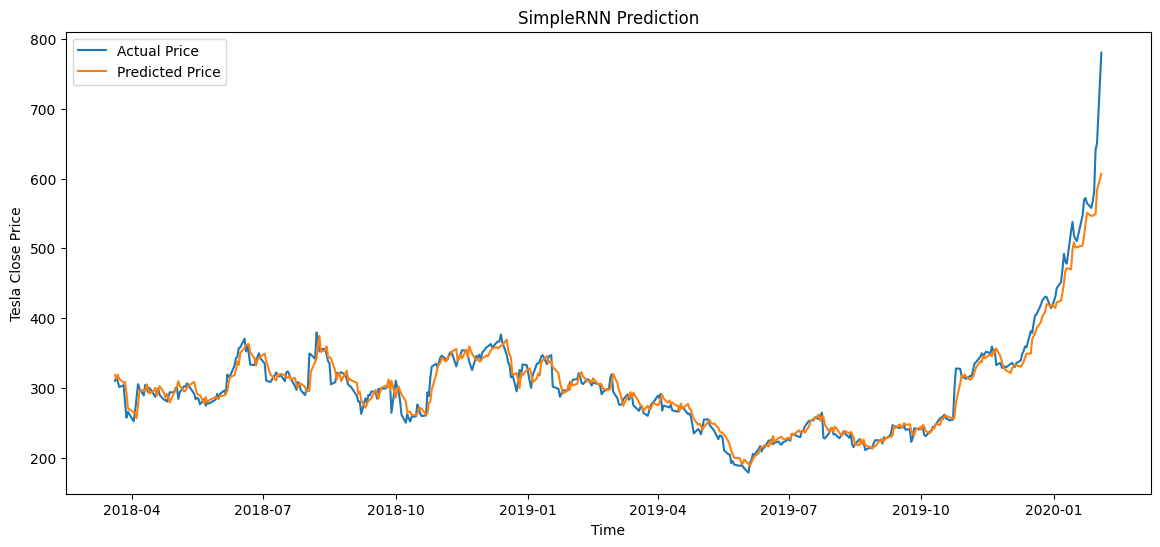

In [60]:
plt.figure(figsize=(14,6))

plt.plot(
    test_dates,
    actual_prices,
    label='Actual Price'
)

plt.plot(
    test_dates,
    rnn_predictions,
    label='Predicted Price'
)

plt.title("SimpleRNN Prediction")
plt.xlabel("Time")
plt.ylabel("Tesla Close Price")

plt.legend()

plt.show()

In [61]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [62]:
mse_rnn = mean_squared_error(
    actual_prices,
    rnn_predictions
)

rmse_rnn = np.sqrt(mse_rnn)

mae_rnn = mean_absolute_error(
    actual_prices,
    rnn_predictions
)

r2_rnn = r2_score(
    actual_prices,
    rnn_predictions
)

print("MSE :", mse_rnn)
print("RMSE:", rmse_rnn)
print("MAE :", mae_rnn)
print("R2  :", r2_rnn)

MSE : 271.617958203237
RMSE: 16.480836089326203
MAE : 10.36480763737255
R2  : 0.9484522593377043


In [63]:
rnn_model.save("../models/simple_rnn_model.keras")

In [64]:
import os
print(os.listdir("../models"))

['best_rnn_model.keras', 'simple_rnn_model.keras']


## LSTM Model

Long Short-Term Memory networks are designed to overcome limitations of traditional RNNs. Through memory cells and gating mechanisms, LSTMs can retain important information over longer time periods.

In [65]:
from tensorflow.keras.layers import LSTM

In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(
    LSTM(
        units=50
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [67]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [69]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '../models/best_lstm_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [70]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0043 - val_loss: 4.5847e-04
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.0453e-04 - val_loss: 5.9561e-04
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.8050e-04 - val_loss: 4.4014e-04
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.5136e-04 - val_loss: 6.2945e-04
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.4618e-04 - val_loss: 6.1064e-04
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.2591e-04 - val_loss: 4.0845e-04
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.7626e-04 - val_loss: 6.6867e-04
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.6221e-04 - val_loss: 6.5172e-04
Epoch 9/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.8255e-04 - val_loss: 5.1920e-04
Epoch 10/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.7181e-04 - val_loss: 7.4033e-04
Epoch 11/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.6330e-04 - 

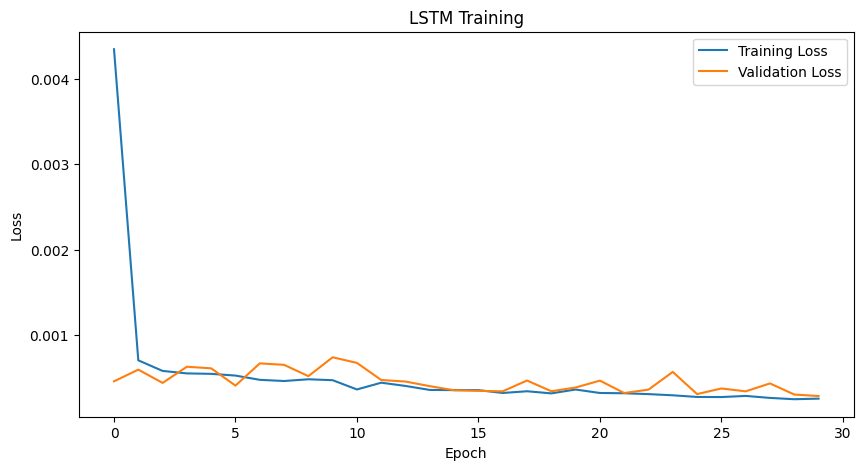

In [71]:
plt.figure(figsize=(10,5))

plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

### LSTM Training Analysis

Compared to the SimpleRNN model, the LSTM demonstrates improved convergence and stronger capability to capture long-term dependencies in stock price movements.

In [72]:
lstm_predictions = lstm_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [73]:
lstm_predictions = scaler.inverse_transform(
    lstm_predictions
)

actual_prices = scaler.inverse_transform(
    y_test
)

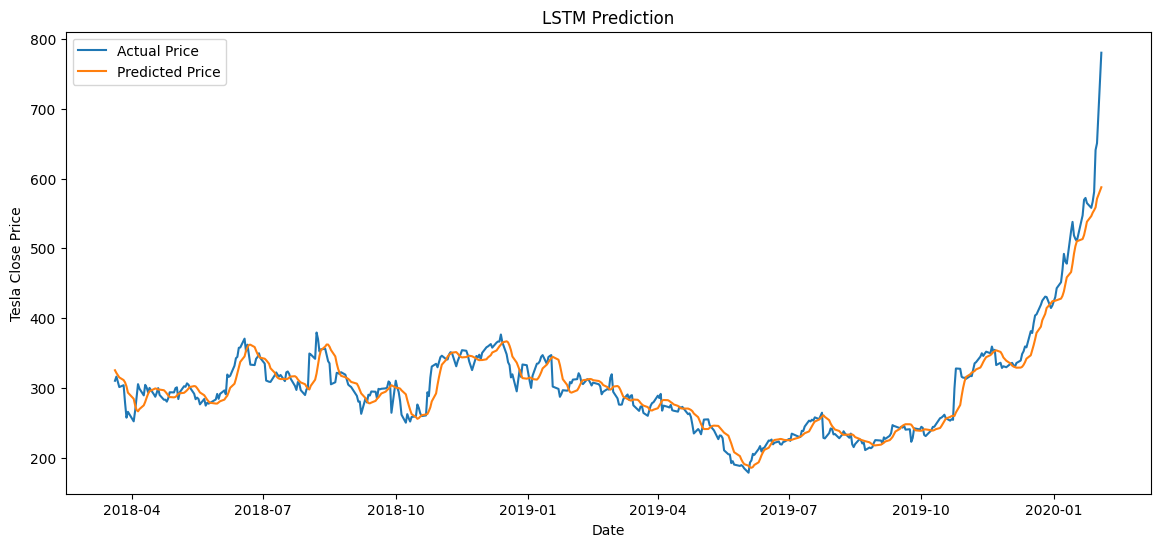

In [74]:
test_dates = data.index[-len(actual_prices):]

plt.figure(figsize=(14,6))

plt.plot(
    test_dates,
    actual_prices,
    label='Actual Price'
)

plt.plot(
    test_dates,
    lstm_predictions,
    label='Predicted Price'
)

plt.title("LSTM Prediction")

plt.xlabel("Date")
plt.ylabel("Tesla Close Price")

plt.legend()

plt.show()

In [75]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

mse_lstm = mean_squared_error(
    actual_prices,
    lstm_predictions
)

rmse_lstm = np.sqrt(mse_lstm)

mae_lstm = mean_absolute_error(
    actual_prices,
    lstm_predictions
)

r2_lstm = r2_score(
    actual_prices,
    lstm_predictions
)

print("MSE :", mse_lstm)
print("RMSE:", rmse_lstm)
print("MAE :", mae_lstm)
print("R2  :", r2_lstm)

MSE : 407.3377312698469
RMSE: 20.182609624868807
MAE : 13.540475372047554
R2  : 0.9226953185556501


In [76]:
lstm_model.save("../models/lstm_model.keras")

In [77]:
comparison = pd.DataFrame({
    'Model':['SimpleRNN','LSTM'],
    'MSE':[mse_rnn,mse_lstm],
    'RMSE':[rmse_rnn,rmse_lstm],
    'MAE':[mae_rnn,mae_lstm],
    'R2':[r2_rnn,r2_lstm]
})

comparison

,Model,MSE,RMSE,MAE,R2
0,SimpleRNN,271.617958,16.480836,10.364808,0.948452
1,LSTM,407.337731,20.182610,13.540475,0.922695


In [78]:
comparison.sort_values(
    by='RMSE'
)

,Model,MSE,RMSE,MAE,R2
0,SimpleRNN,271.617958,16.480836,10.364808,0.948452
1,LSTM,407.337731,20.182610,13.540475,0.922695


In [79]:
from tensorflow.keras.optimizers import Adam

In [80]:
def build_lstm_model(units, dropout_rate, learning_rate):

    model = Sequential()

    model.add(
        LSTM(
            units=units,
            return_sequences=True,
            input_shape=(X_train.shape[1], X_train.shape[2])
        )
    )

    model.add(Dropout(dropout_rate))

    model.add(LSTM(units))

    model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mean_squared_error'
    )

    return model

In [81]:
units_list = [32, 64]

dropout_list = [0.2, 0.3]

learning_rate_list = [0.001, 0.0001]

In [82]:
results = []

In [83]:
for units in units_list:

    for dropout in dropout_list:

        for lr in learning_rate_list:

            print(
                f"Units={units}, "
                f"Dropout={dropout}, "
                f"LR={lr}"
            )

            model = build_lstm_model(
                units,
                dropout,
                lr
            )

            history = model.fit(
                X_train,
                y_train,
                epochs=10,
                batch_size=32,
                validation_split=0.1,
                verbose=0
            )

            best_val_loss = min(
                history.history['val_loss']
            )

            results.append([
                units,
                dropout,
                lr,
                best_val_loss
            ])

Units=32, Dropout=0.2, LR=0.001


/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Units=32, Dropout=0.2, LR=0.0001
Units=32, Dropout=0.3, LR=0.001
Units=32, Dropout=0.3, LR=0.0001
Units=64, Dropout=0.2, LR=0.001
Units=64, Dropout=0.2, LR=0.0001
Units=64, Dropout=0.3, LR=0.001
Units=64, Dropout=0.3, LR=0.0001


In [84]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Units',
        'Dropout',
        'Learning Rate',
        'Val Loss'
    ]
)

results_df

,Units,Dropout,Learning Rate,Val Loss
0,32,0.2,0.0010,0.000404
1,32,0.2,0.0001,0.000696
2,32,0.3,0.0010,0.000415
3,32,0.3,0.0001,0.000548
4,64,0.2,0.0010,0.000402
5,64,0.2,0.0001,0.000589
6,64,0.3,0.0010,0.000409
7,64,0.3,0.0001,0.000568


In [85]:
results_df.sort_values(
    by='Val Loss'
)

,Units,Dropout,Learning Rate,Val Loss
4,64,0.2,0.0010,0.000402
0,32,0.2,0.0010,0.000404
6,64,0.3,0.0010,0.000409
2,32,0.3,0.0010,0.000415
3,32,0.3,0.0001,0.000548
7,64,0.3,0.0001,0.000568
5,64,0.2,0.0001,0.000589
1,32,0.2,0.0001,0.000696


In [86]:
best_row = results_df.sort_values(
    by='Val Loss'
).iloc[0]

best_row

Units            64.000000
Dropout           0.200000
Learning Rate     0.001000
Val Loss          0.000402
Name: 4, dtype: float64

In [87]:
final_lstm = build_lstm_model(
    units=int(best_row['Units']),
    dropout_rate=float(best_row['Dropout']),
    learning_rate=float(best_row['Learning Rate'])
)

/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [88]:
history_final = final_lstm.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0023 - val_loss: 5.7957e-04
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.0093e-04 - val_loss: 4.2854e-04
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.1782e-04 - val_loss: 4.2702e-04
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.7314e-04 - val_loss: 4.1763e-04
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.1093e-04 - val_loss: 3.9913e-04
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.1132e-04 - val_loss: 3.9666e-04
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.6413e-04 - val_loss: 3.7851e-04
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.8092e-04 - val_loss: 3.7520e-04
Epoch 9/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.4579e-04 - val_loss: 3.6419e-04
Epoch 10/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.2927e-04 - val_loss: 4.0190e-04


In [89]:
final_predictions = final_lstm.predict(X_test)

final_predictions = scaler.inverse_transform(
    final_predictions
)

actual_prices = scaler.inverse_transform(
    y_test
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [90]:
mse_final = mean_squared_error(
    actual_prices,
    final_predictions
)

rmse_final = np.sqrt(mse_final)

mae_final = mean_absolute_error(
    actual_prices,
    final_predictions
)

r2_final = r2_score(
    actual_prices,
    final_predictions
)

print("RMSE:", rmse_final)
print("MAE :", mae_final)
print("R2  :", r2_final)

RMSE: 28.55724116781005
MAE : 20.820157527248575
R2  : 0.8452311152633747


In [91]:
final_lstm.save(
    "../models/final_lstm_model.keras"
)

In [92]:
X1, y1 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=1
)

In [93]:
X5, y5 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=5
)

In [94]:
X10, y10 = create_sequences(
    scaled_data,
    lookback=60,
    horizon=10
)

## Model Performance Comparison

Both models are evaluated using RMSE and visual comparison of predicted versus actual stock prices.

In [95]:
from sklearn.metrics import mean_squared_error
import numpy as np

rnn_rmse = np.sqrt(mean_squared_error(y_test, rnn_predictions))
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_predictions))

print("RNN RMSE:", rnn_rmse)
print("LSTM RMSE:", lstm_rmse)

RNN RMSE: 307.5922919569913
LSTM RMSE: 306.27146490467646


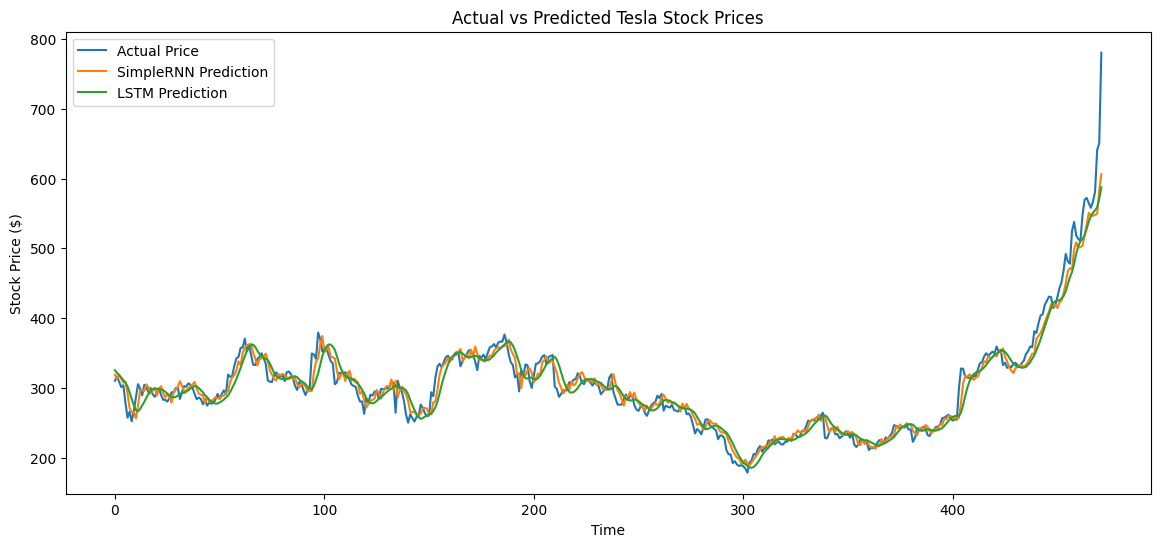

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    rnn_predictions,
    label="SimpleRNN Prediction"
)

plt.plot(
    lstm_predictions,
    label="LSTM Prediction"
)

plt.title("Actual vs Predicted Tesla Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price ($)")
plt.legend()

plt.show()

### Performance Analysis

The LSTM model follows the actual stock price trend more closely than the SimpleRNN model. Lower prediction errors and smoother tracking of market movements indicate superior forecasting capability.

Based on these results, the LSTM architecture is selected for deployment.

## Multi-Horizon Forecasting

To evaluate forecasting performance across different time horizons, separate LSTM models are trained for:

- 1-Day Ahead Prediction
- 5-Day Ahead Prediction
- 10-Day Ahead Prediction

This allows analysis of how prediction accuracy changes as the forecast horizon increases.

In [97]:
def split_data(X, y):

    train_size = int(len(X)*0.8)

    X_train = X[:train_size]
    X_test = X[train_size:]

    y_train = y[:train_size]
    y_test = y[train_size:]

    return X_train, X_test, y_train, y_test

In [98]:
X1_train, X1_test, y1_train, y1_test = split_data(X1, y1)

X5_train, X5_test, y5_train, y5_test = split_data(X5, y5)

X10_train, X10_test, y10_train, y10_test = split_data(X10, y10)

In [99]:
def build_final_model():

    model = Sequential()

    model.add(
        LSTM(
            64,
            return_sequences=True,
            input_shape=(60,1)
        )
    )

    model.add(Dropout(0.2))

    model.add(LSTM(64))

    model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(0.001),
        loss='mean_squared_error'
    )

    return model

In [100]:
model_1day = build_final_model()

model_1day.fit(
    X1_train,
    y1_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30


/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0027 - val_loss: 4.6557e-04
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.6939e-04 - val_loss: 4.5059e-04
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.1126e-04 - val_loss: 5.7197e-04
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.4451e-04 - val_loss: 4.8941e-04
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.0731e-04 - val_loss: 5.5113e-04
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.2776e-04 - val_loss: 4.3551e-04
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.2337e-04 - val_loss: 6.6078e-04
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.9742e-04 - val_loss: 3.8059e-04
Epoch 9/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.1830e-04 - val_loss: 4.2254e-04
Epoch 10/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.0901e-04 - val_loss: 6.5030e-04
Epoch 11/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.0966e-04 - val_loss: 8

In [101]:
model_1day.save(
    "../models/model_1day.keras"
)

In [102]:
pred1 = model_1day.predict(X1_test)

pred1 = scaler.inverse_transform(pred1)

actual1 = scaler.inverse_transform(y1_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [103]:
rmse_1 = np.sqrt(
    mean_squared_error(
        actual1,
        pred1
    )
)

print(rmse_1)

19.87509827991447


In [104]:
model_5day = build_final_model()

model_5day.fit(
    X5_train,
    y5_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30


/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0038 - val_loss: 9.1891e-04
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.1617e-04 - val_loss: 0.0010
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.6349e-04 - val_loss: 7.3196e-04
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.4988e-04 - val_loss: 6.5224e-04
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.0313e-04 - val_loss: 7.4389e-04
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.2029e-04 - val_loss: 7.3064e-04
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.5428e-04 - val_loss: 8.0956e-04
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.8893e-04 - val_loss: 7.1887e-04
Epoch 9/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.9331e-04 - val_loss: 0.0010
Epoch 10/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.3348e-04 - val_loss: 7.6500e-04
Epoch 11/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.0820e-04 - val_loss: 7.4308e-0

In [105]:
model_5day.save(
    "../models/model_5day.keras"
)

In [106]:
pred5 = model_5day.predict(X5_test)

pred5 = scaler.inverse_transform(pred5)

actual5 = scaler.inverse_transform(y5_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [107]:
rmse_5 = np.sqrt(
    mean_squared_error(
        actual5,
        pred5
    )
)

print(rmse_5)

33.931956525620464


In [108]:
model_10day = build_final_model()

model_10day.fit(
    X10_train,
    y10_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30


/Users/rudranildatta/Desktop/internship/project3-tesla/Tesla_Stock_Prediction/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0057 - val_loss: 8.5916e-04
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.1095e-04 - val_loss: 8.5728e-04
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.1497e-04 - val_loss: 9.4012e-04
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.2456e-04 - val_loss: 0.0011
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.0521e-04 - val_loss: 0.0011
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.8509e-04 - val_loss: 0.0010
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.6766e-04 - val_loss: 8.3456e-04
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.0923e-04 - val_loss: 0.0011
Epoch 9/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.0781e-04 - val_loss: 9.5683e-04
Epoch 10/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.4292e-04 - val_loss: 0.0017
Epoch 11/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.0344e-04 - val_loss: 0.0011
Epoch 12/30
53

In [109]:
model_10day.save(
    "../models/model_10day.keras"
)

In [110]:
pred10 = model_10day.predict(X10_test)

pred10 = scaler.inverse_transform(pred10)

actual10 = scaler.inverse_transform(y10_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [111]:
rmse_10 = np.sqrt(
    mean_squared_error(
        actual10,
        pred10
    )
)

print(rmse_10)

43.3474779620841


In [112]:
forecast_results = pd.DataFrame({

    'Forecast Horizon': [
        '1 Day',
        '5 Days',
        '10 Days'
    ],

    'RMSE': [
        rmse_1,
        rmse_5,
        rmse_10
    ]
})

forecast_results

,Forecast Horizon,RMSE
0,1 Day,19.875098
1,5 Days,33.931957
2,10 Days,43.347478


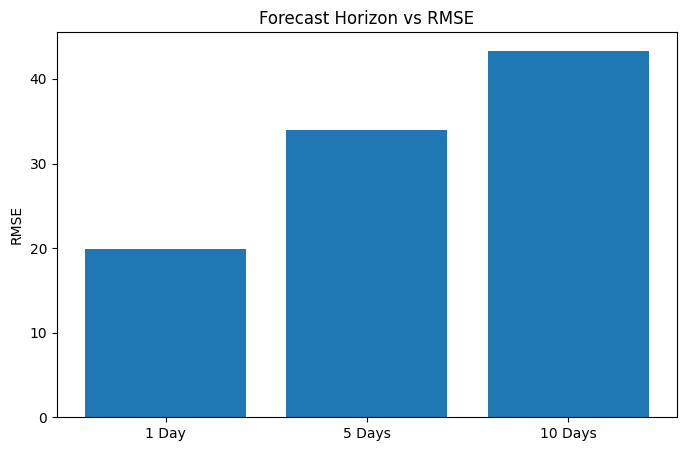

In [113]:
plt.figure(figsize=(8,5))

plt.bar(
    forecast_results['Forecast Horizon'],
    forecast_results['RMSE']
)

plt.title(
    'Forecast Horizon vs RMSE'
)

plt.ylabel('RMSE')

plt.show()

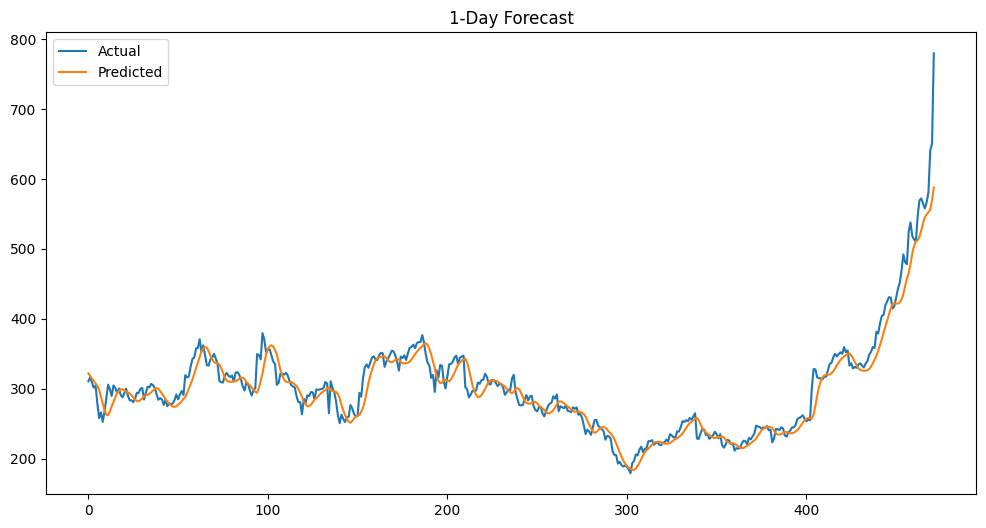

In [114]:
plt.figure(figsize=(12,6))

plt.plot(actual1, label='Actual')
plt.plot(pred1, label='Predicted')

plt.title('1-Day Forecast')

plt.legend()

plt.show()

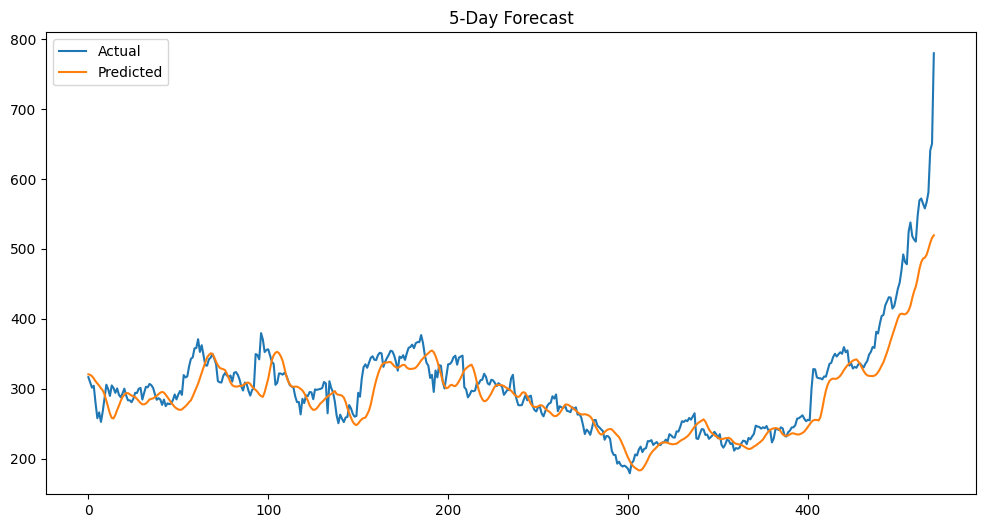

In [115]:
plt.figure(figsize=(12,6))

plt.plot(actual5, label='Actual')
plt.plot(pred5, label='Predicted')

plt.title('5-Day Forecast')

plt.legend()

plt.show()

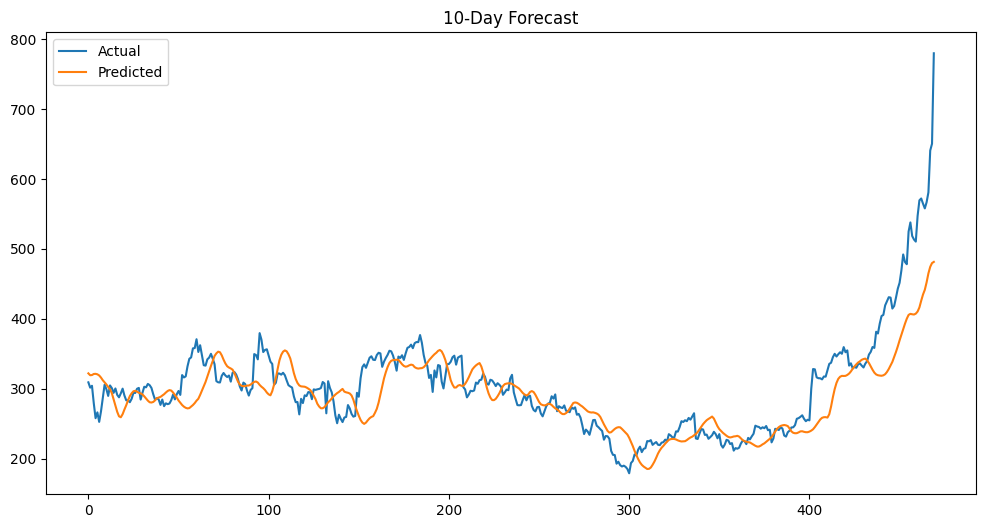

In [116]:
plt.figure(figsize=(12,6))

plt.plot(actual10, label='Actual')
plt.plot(pred10, label='Predicted')

plt.title('10-Day Forecast')

plt.legend()

plt.show()

# Conclusion

This project successfully demonstrates the application of Deep Learning to stock market forecasting.

Key findings:

- Both SimpleRNN and LSTM models were capable of learning stock price patterns.
- LSTM achieved superior performance due to its ability to capture long-term dependencies.
- Prediction accuracy decreases as forecasting horizons increase.
- Historical closing prices alone provide useful predictive information but cannot fully capture market dynamics.

Suggested Improvements

Several enhancements can be made to improve forecasting performance in future work. Additional features such as trading volume, opening price, highest price, lowest price, and technical indicators like RSI, MACD, and Moving Averages can be incorporated into the model. News sentiment analysis using Natural Language Processing (NLP) techniques can help capture market reactions to company announcements and financial news. Macroeconomic indicators such as inflation rates, interest rates, unemployment statistics, and major market indices can also be integrated to provide broader economic context. Furthermore, advanced architectures such as GRU networks, Transformer-based models, and hybrid deep learning approaches may improve forecasting accuracy and robustness.


Limitations

Although the models demonstrated the ability to forecast Tesla stock prices with reasonable accuracy, several limitations remain. The models were trained primarily on historical closing prices and therefore do not consider external factors that significantly influence stock market behavior. Sudden market fluctuations caused by earnings reports, company announcements, geopolitical events, economic policies, or investor sentiment cannot be fully captured using historical price data alone. Additionally, forecasting accuracy decreases as the prediction horizon increases, making long-term predictions more challenging than short-term forecasts. Stock markets are inherently volatile and contain a degree of randomness that no model can predict perfectly.